# 04 — Scenario 5: Dimensionality Reduction Before Classification

Goal: test whether PCA or LDA projections can compress the WAP feature
space while preserving building-floor classification quality. PCA is
unsupervised; LDA projection is supervised and limited to `n_classes - 1`
discriminant axes.

In [1]:
# --- bootstrap: make src/ importable when notebook started outside `uv run` ---
import sys
from pathlib import Path

_HERE = Path.cwd()
for parent in [_HERE, *_HERE.parents]:
    if (parent / "src" / "ujiindoorloc").is_dir():
        if str(parent / "src") not in sys.path:
            sys.path.insert(0, str(parent / "src"))
        break

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [2]:
import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from ujiindoorloc.constants import COMBINED_TARGET, FIGURES_DIR, MODELS_DIR, RANDOM_STATE, TABLES_DIR
from ujiindoorloc.data_loading import load_raw_data, split_features_targets
from ujiindoorloc.preprocessing import prepare_classification_data
from ujiindoorloc import modeling as M
from ujiindoorloc import evaluation as E
from ujiindoorloc import plots as P
from ujiindoorloc.reporting import ensure_report_dirs, save_table

ensure_report_dirs()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
raw = load_raw_data()
split = split_features_targets(raw.train, raw.valid, target_name=COMBINED_TARGET)
prepared = prepare_classification_data(split.X_train, split.X_valid)

Xs_tr, Xs_va = prepared.X_train_scaled, prepared.X_valid_scaled
Xt_tr, Xt_va = prepared.X_train_tree, prepared.X_valid_tree
y_tr, y_va = np.asarray(split.y_train), np.asarray(split.y_valid)
print("scaled X:", Xs_tr.shape)
print("tree X  :", Xt_tr.shape)

scaled X: (19937, 465)
tree X  : (19937, 465)


## PCA explained variance

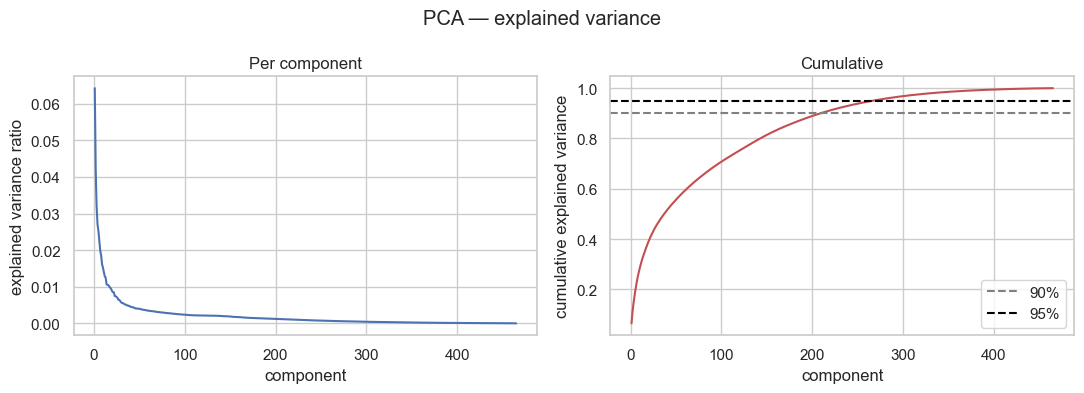

  k=  2: cumulative variance =  10.6%
  k=  5: cumulative variance =  19.1%
  k= 10: cumulative variance =  28.3%
  k= 20: cumulative variance =  39.3%
  k= 30: cumulative variance =  46.3%
  k= 50: cumulative variance =  55.7%
  k= 75: cumulative variance =  64.1%
  k=100: cumulative variance =  70.8%


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.064230,0.064230
1,2,0.042269,0.106499
2,3,0.032104,0.138603
3,4,0.027127,0.165730
4,5,0.025305,0.191035
5,6,0.022550,0.213586
6,7,0.019880,0.233465
7,8,0.018601,0.252066
8,9,0.016185,0.268251
9,10,0.015206,0.283458


In [4]:
pca_full = PCA(random_state=RANDOM_STATE).fit(Xs_tr)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

var_df = pd.DataFrame({
    "component": np.arange(1, len(evr) + 1),
    "explained_variance_ratio": evr,
    "cumulative_explained_variance": cum,
})
save_table(var_df, "scenario_5_pca_explained_variance.csv")
P.plot_pca_explained_variance(
    evr,
    FIGURES_DIR / "scenario_5_pca_explained_variance.png",
)

for k in [2, 5, 10, 20, 30, 50, 75, 100]:
    if k <= len(cum):
        print(f"  k={k:>3d}: cumulative variance = {cum[k-1]*100:5.1f}%")
display(var_df.head(10))

## PCA 2D scatter

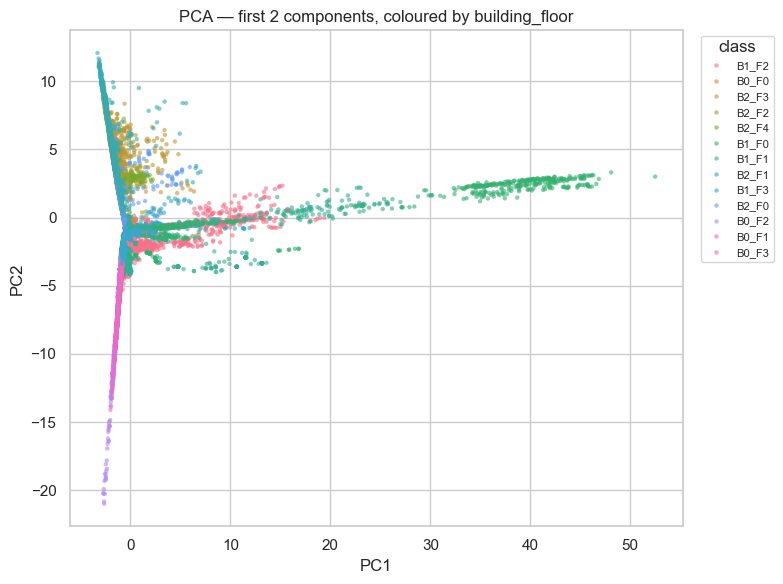

PosixPath('/Users/andrejvysny/fiit/oznal-python/reports/figures/scenario_5_pca_2d_scatter.png')

In [5]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xs_tr)
pcs2 = pca2.transform(Xs_tr)
P.plot_pca_2d_scatter(
    pcs2,
    y_tr,
    FIGURES_DIR / "scenario_5_pca_2d_scatter.png",
    title="PCA — first 2 components, coloured by building_floor",
)

## PCA + classifier sweep

PCA(  2) + logistic_regression  bal_acc=0.246 macro_f1=0.202
PCA(  2) + knn                  bal_acc=0.304 macro_f1=0.277


PCA(  5) + logistic_regression  bal_acc=0.428 macro_f1=0.364
PCA(  5) + knn                  bal_acc=0.507 macro_f1=0.464


PCA( 10) + logistic_regression  bal_acc=0.623 macro_f1=0.580
PCA( 10) + knn                  bal_acc=0.626 macro_f1=0.601


PCA( 20) + logistic_regression  bal_acc=0.796 macro_f1=0.758
PCA( 20) + knn                  bal_acc=0.784 macro_f1=0.776


PCA( 30) + logistic_regression  bal_acc=0.826 macro_f1=0.814
PCA( 30) + knn                  bal_acc=0.799 macro_f1=0.796


PCA( 50) + logistic_regression  bal_acc=0.870 macro_f1=0.856
PCA( 50) + knn                  bal_acc=0.804 macro_f1=0.800


PCA( 75) + logistic_regression  bal_acc=0.872 macro_f1=0.859
PCA( 75) + knn                  bal_acc=0.804 macro_f1=0.799


PCA(100) + logistic_regression  bal_acc=0.877 macro_f1=0.867
PCA(100) + knn                  bal_acc=0.812 macro_f1=0.808


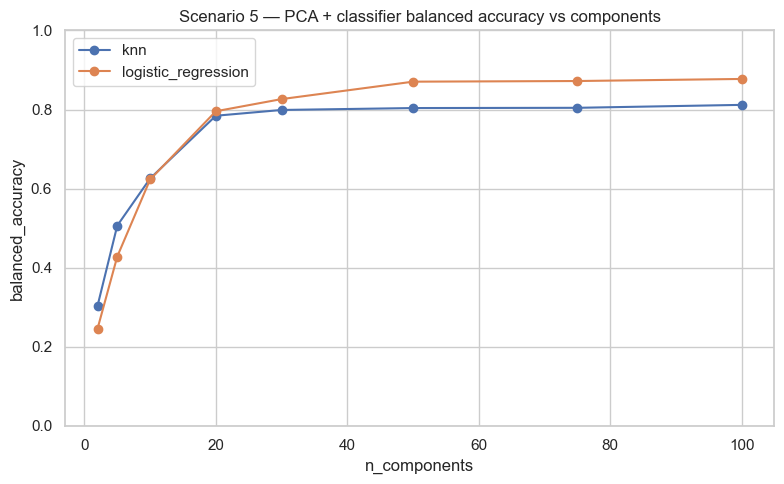

,reduction_method,classifier_name,n_components,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,PCA,logistic_regression,2,0.252025,0.245923,0.202484,0.230220
1,PCA,knn,2,0.306931,0.303705,0.277112,0.315338
2,PCA,logistic_regression,5,0.381638,0.428332,0.363586,0.378684
3,PCA,knn,5,0.459046,0.506502,0.463576,0.458380
4,PCA,logistic_regression,10,0.576058,0.623191,0.579806,0.581010
5,PCA,knn,10,0.581458,0.625710,0.600685,0.584271
6,PCA,logistic_regression,20,0.770477,0.795640,0.758234,0.775416
7,PCA,knn,20,0.790279,0.784296,0.776413,0.791980
8,PCA,logistic_regression,30,0.830783,0.826382,0.814419,0.831529
9,PCA,knn,30,0.813681,0.798886,0.795786,0.814501


In [6]:
component_grid = [2, 5, 10, 20, 30, 50, 75, 100]
pca_rows = []
for k in component_grid:
    for classifier_name, build in [
        ("logistic_regression", lambda k=k: M.build_pca_logistic_pipeline(k)),
        ("knn",                 lambda k=k: M.build_pca_knn_pipeline(k)),
    ]:
        result = E.evaluate_classifier(
            build(),
            Xs_tr,
            y_tr,
            Xs_va,
            y_va,
            name=f"pca_{classifier_name}_{k}",
        )
        pca_rows.append(
            {
                "reduction_method": "PCA",
                "classifier_name": classifier_name,
                "n_components": k,
                "accuracy": result.metrics["accuracy"],
                "balanced_accuracy": result.metrics["balanced_accuracy"],
                "macro_f1": result.metrics["macro_f1"],
                "weighted_f1": result.metrics["weighted_f1"],
            }
        )
        print(
            f"PCA({k:>3d}) + {classifier_name:20s} "
            f"bal_acc={result.metrics['balanced_accuracy']:.3f} "
            f"macro_f1={result.metrics['macro_f1']:.3f}"
        )

pca_metrics_df = pd.DataFrame(pca_rows)
save_table(pca_metrics_df, "scenario_5_pca_metrics.csv")
P.plot_metric_vs_components(
    pca_metrics_df,
    FIGURES_DIR / "scenario_5_pca_metric_vs_components.png",
    title="Scenario 5 — PCA + classifier balanced accuracy vs components",
    metric="balanced_accuracy",
    model_col="classifier_name",
)
display(pca_metrics_df)

## LDA projection before classification

n_classes: 13   max LDA components: 12


LDA( 2) + logistic_regression  bal_acc=0.412 macro_f1=0.373


LDA( 2) + knn                  bal_acc=0.537 macro_f1=0.515


LDA( 5) + logistic_regression  bal_acc=0.806 macro_f1=0.795


LDA( 5) + knn                  bal_acc=0.798 macro_f1=0.790


LDA(10) + logistic_regression  bal_acc=0.890 macro_f1=0.882


LDA(10) + knn                  bal_acc=0.870 macro_f1=0.856


LDA(12) + logistic_regression  bal_acc=0.885 macro_f1=0.868


LDA(12) + knn                  bal_acc=0.885 macro_f1=0.866


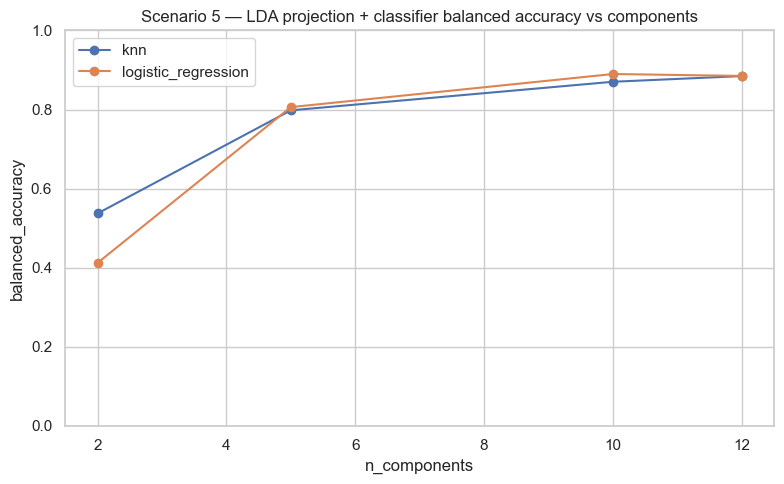

,reduction_method,classifier_name,n_components,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,LDA_projection,logistic_regression,2,0.530153,0.412149,0.372626,0.519859
1,LDA_projection,knn,2,0.632763,0.537249,0.515062,0.633525
2,LDA_projection,logistic_regression,5,0.841584,0.806072,0.794549,0.842969
3,LDA_projection,knn,5,0.826283,0.797956,0.789990,0.827946
4,LDA_projection,logistic_regression,10,0.905491,0.889765,0.881538,0.905063
5,LDA_projection,knn,10,0.889289,0.870163,0.855930,0.890139
6,LDA_projection,logistic_regression,12,0.892889,0.884956,0.867723,0.892555
7,LDA_projection,knn,12,0.893789,0.884601,0.865674,0.893810


In [7]:
n_classes = len(np.unique(y_tr))
max_lda = min(n_classes - 1, Xs_tr.shape[1])
lda_components = [c for c in [2, 5, 10, 12] if c <= max_lda]
print("n_classes:", n_classes, "  max LDA components:", max_lda)

lda_rows = []
for n in lda_components:
    for classifier_name, build in [
        ("logistic_regression", lambda n=n: M.build_lda_projection_logistic_pipeline(n_components=n)),
        ("knn",                 lambda n=n: M.build_lda_projection_knn_pipeline(n_components=n)),
    ]:
        result = E.evaluate_classifier(
            build(),
            Xs_tr,
            y_tr,
            Xs_va,
            y_va,
            name=f"lda_projection_{classifier_name}_{n}",
        )
        lda_rows.append(
            {
                "reduction_method": "LDA_projection",
                "classifier_name": classifier_name,
                "n_components": n,
                "accuracy": result.metrics["accuracy"],
                "balanced_accuracy": result.metrics["balanced_accuracy"],
                "macro_f1": result.metrics["macro_f1"],
                "weighted_f1": result.metrics["weighted_f1"],
            }
        )
        print(
            f"LDA({n:>2d}) + {classifier_name:20s} "
            f"bal_acc={result.metrics['balanced_accuracy']:.3f} "
            f"macro_f1={result.metrics['macro_f1']:.3f}"
        )

lda_metrics_df = pd.DataFrame(lda_rows)
save_table(lda_metrics_df, "scenario_5_lda_projection_metrics.csv")
P.plot_metric_vs_components(
    lda_metrics_df,
    FIGURES_DIR / "scenario_5_lda_projection_metric_vs_components.png",
    title="Scenario 5 — LDA projection + classifier balanced accuracy vs components",
    metric="balanced_accuracy",
    model_col="classifier_name",
)
display(lda_metrics_df)

## LDA 2D visualization

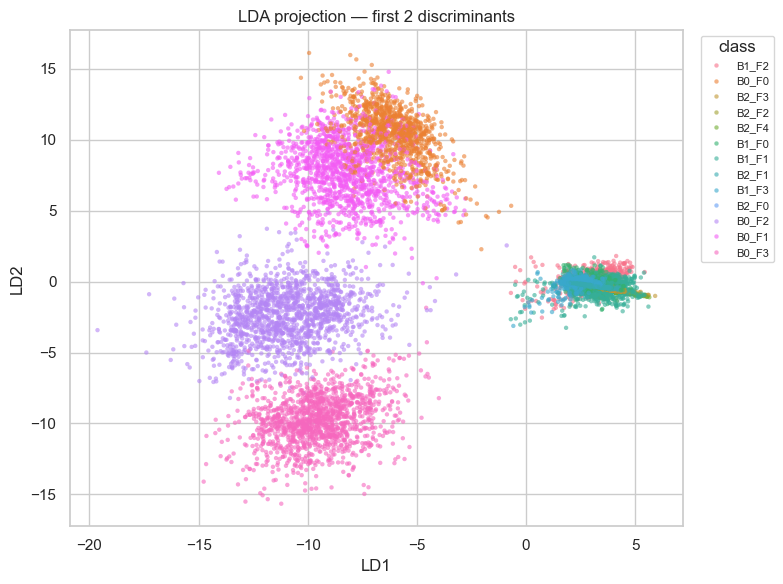

In [8]:
if max_lda >= 2:
    lda2 = LinearDiscriminantAnalysis(n_components=2, solver="svd")
    lda2_projection = lda2.fit_transform(Xs_tr, y_tr)
    P.plot_2d_projection_scatter(
        lda2_projection,
        y_tr,
        FIGURES_DIR / "scenario_5_lda_2d_scatter.png",
        title="LDA projection — first 2 discriminants",
        x_label="LD1",
        y_label="LD2",
    )
else:
    print("LDA 2D visualization skipped: fewer than 2 discriminants available.")

## Select best dimensionality reduction model

In [9]:
pca_metrics = pd.read_csv(TABLES_DIR / "scenario_5_pca_metrics.csv")
lda_metrics = pd.read_csv(TABLES_DIR / "scenario_5_lda_projection_metrics.csv")
all_dr_metrics = pd.concat([pca_metrics, lda_metrics], ignore_index=True)

best_balanced_accuracy = all_dr_metrics["balanced_accuracy"].max()
near_best = all_dr_metrics[
    all_dr_metrics["balanced_accuracy"] >= best_balanced_accuracy - 0.01
]
best_row = near_best.sort_values(
    ["n_components", "balanced_accuracy", "macro_f1"],
    ascending=[True, False, False],
).iloc[0]

if best_row["reduction_method"] == "PCA":
    best_pipeline = M.build_pca_logistic_pipeline(n_components=int(best_row["n_components"]))             if best_row["classifier_name"] == "logistic_regression"             else M.build_pca_knn_pipeline(n_components=int(best_row["n_components"]))
elif best_row["reduction_method"] == "LDA_projection":
    best_pipeline = M.build_lda_projection_logistic_pipeline(n_components=int(best_row["n_components"]))             if best_row["classifier_name"] == "logistic_regression"             else M.build_lda_projection_knn_pipeline(n_components=int(best_row["n_components"]))
else:
    raise ValueError(f"Unknown reduction method: {best_row['reduction_method']}")

best_pipeline.fit(Xs_tr, y_tr)
best_path = MODELS_DIR / "scenario_5_best_dimensionality_reduction_model.joblib"
joblib.dump(best_pipeline, best_path)

print(
    "Selected",
    f"{best_row['reduction_method']} + {best_row['classifier_name']}",
    f"with {int(best_row['n_components'])} components."
)
print(
    f"balanced_accuracy={best_row['balanced_accuracy']:.3f}, "
    f"macro_f1={best_row['macro_f1']:.3f}. "
    "Selection uses candidates within 0.01 balanced_accuracy of the best, "
    "then prefers fewer components."
)
print("Saved best dimensionality-reduction pipeline to:", best_path)

Selected LDA_projection + logistic_regression with 10 components.
balanced_accuracy=0.890, macro_f1=0.882. Selection uses candidates within 0.01 balanced_accuracy of the best, then prefers fewer components.
Saved best dimensionality-reduction pipeline to: /Users/andrejvysny/fiit/oznal-python/models/scenario_5_best_dimensionality_reduction_model.joblib


## Scenario 5 conclusion

PCA answers how much unsupervised compression is possible; LDA answers how
compact a supervised class-separating representation can be. The selected
pipeline is saved for reuse, while the final notebook compares this reduced
model against the best original-feature models from Scenario 2.